# Free Cash Flow Time Series Plotter
## Legge  i CSV generati e plotta FCF quarter by quarter

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [4]:
# Leggi la lista dei ticker dal file
def load_tickers_only(filename='tickers.txt'):
    """Carica solo i ticker dal file di configurazione"""
    tickers = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                parts = line.split(',')
                if len(parts) == 2:
                    ticker = parts[1].strip()
                    tickers.append(ticker)
    return tickers

TICKERS = load_tickers_only('tickers.txt')

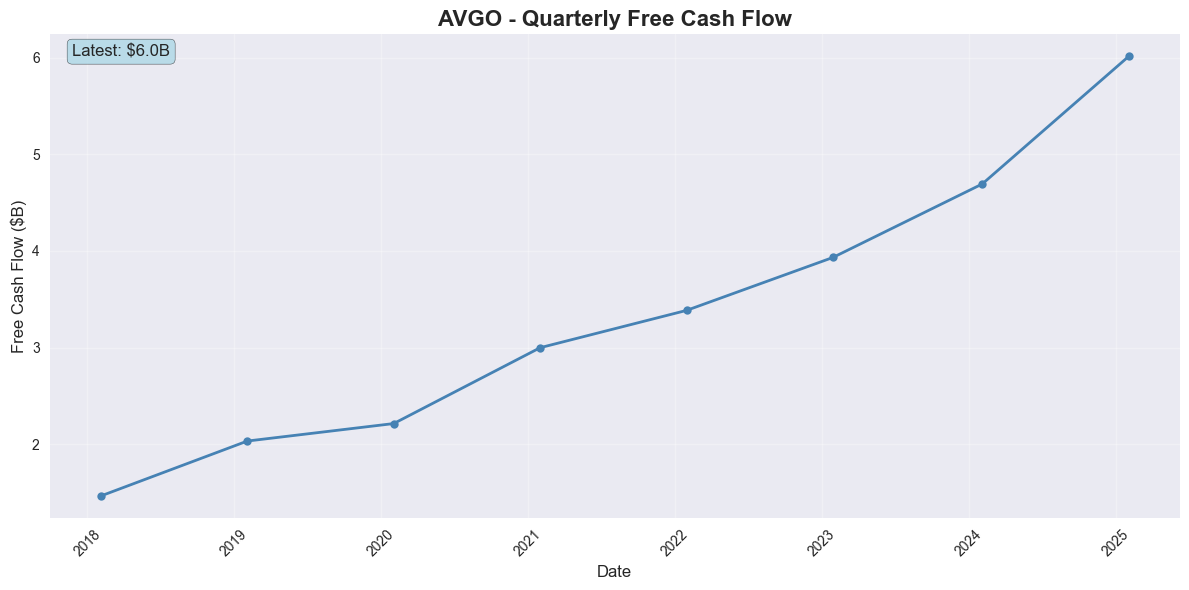

✓ Grafico salvato: result/AVGO_fcf_quarterly.png


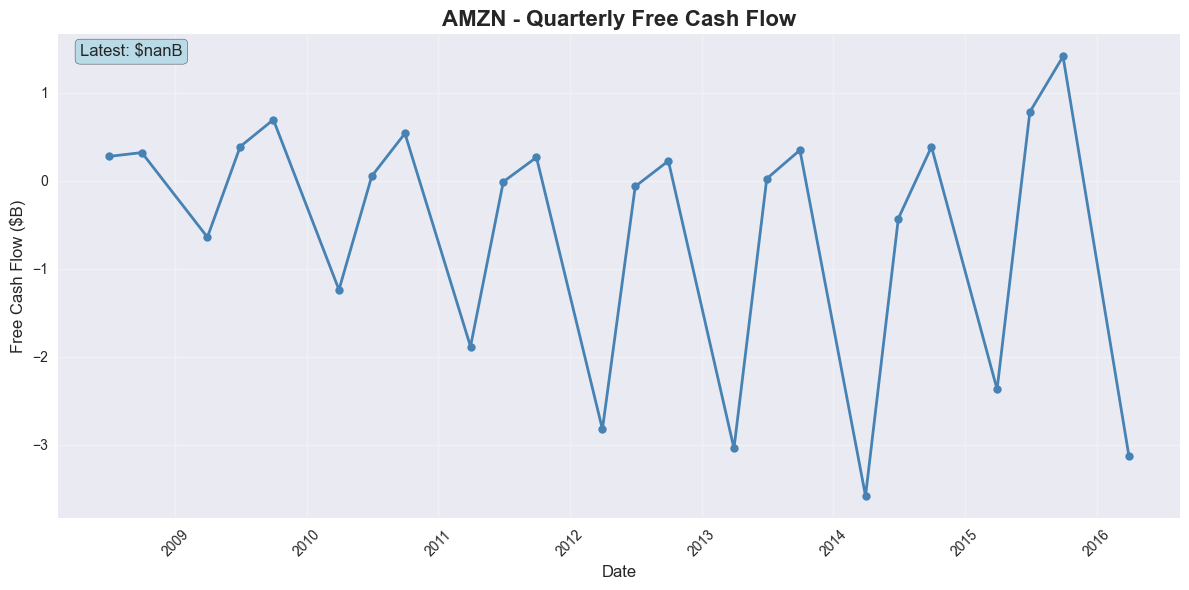

✓ Grafico salvato: result/AMZN_fcf_quarterly.png


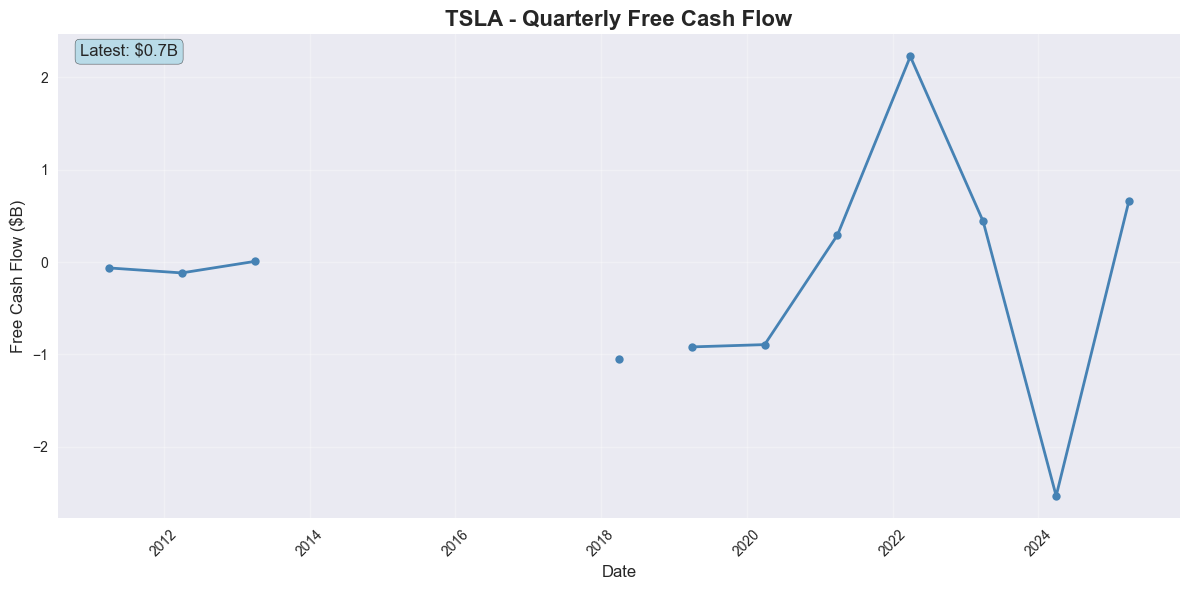

✓ Grafico salvato: result/TSLA_fcf_quarterly.png


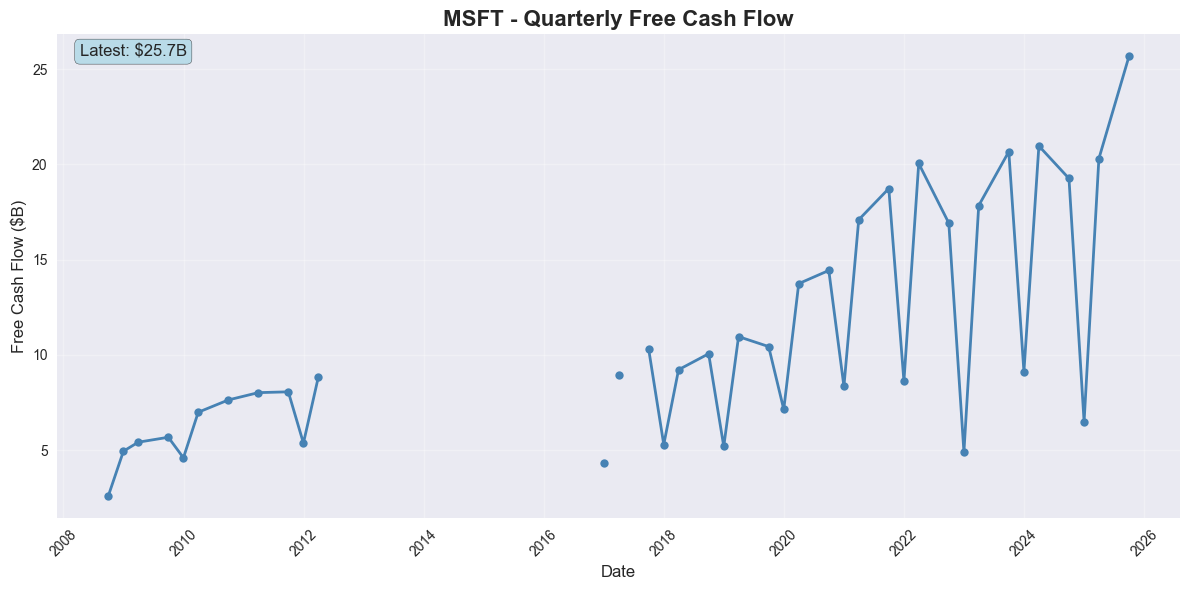

✓ Grafico salvato: result/MSFT_fcf_quarterly.png


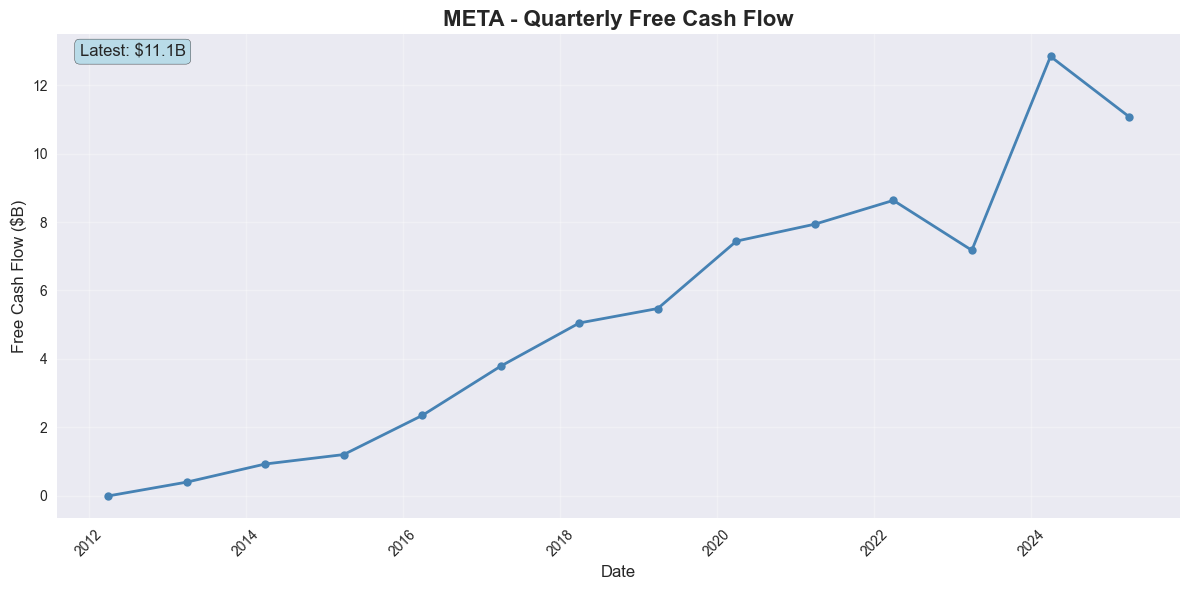

✓ Grafico salvato: result/META_fcf_quarterly.png


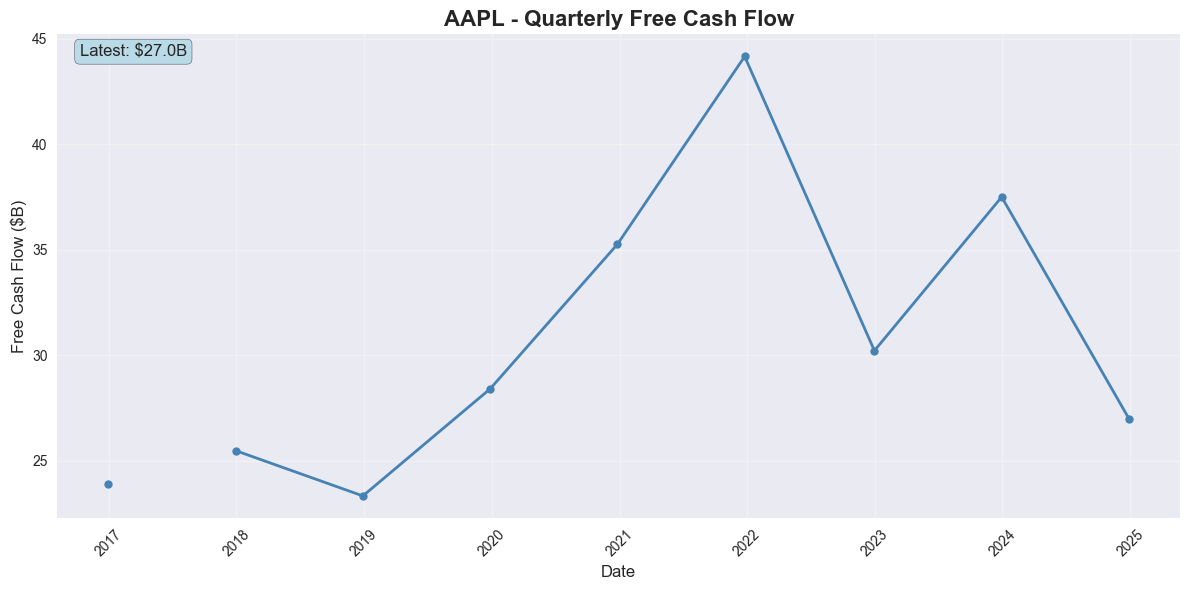

✓ Grafico salvato: result/AAPL_fcf_quarterly.png


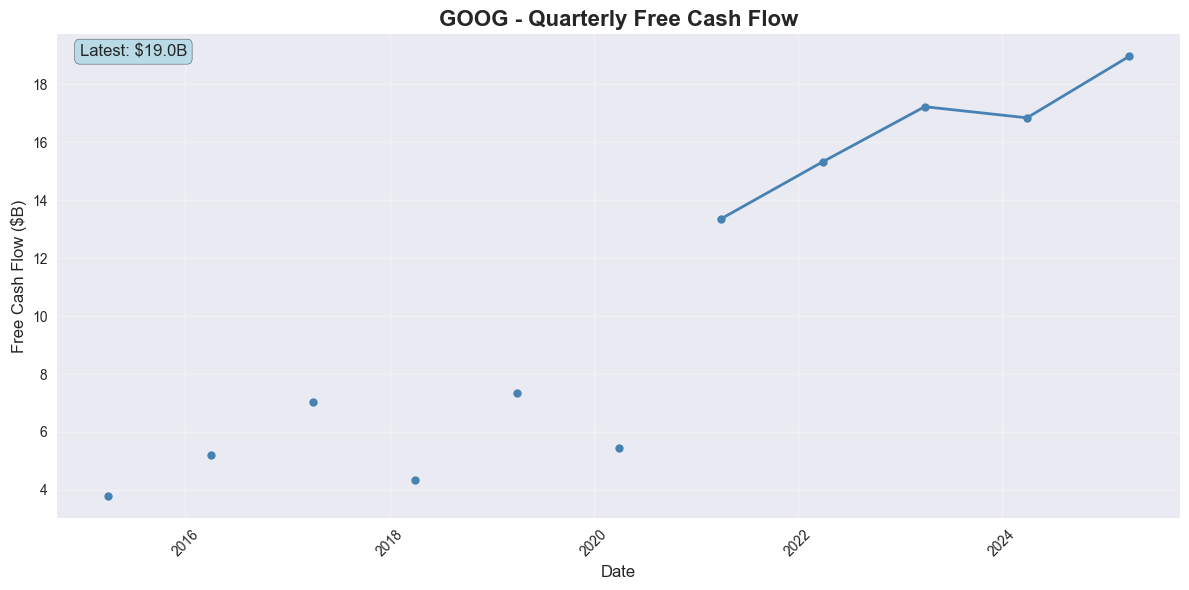

✓ Grafico salvato: result/GOOG_fcf_quarterly.png


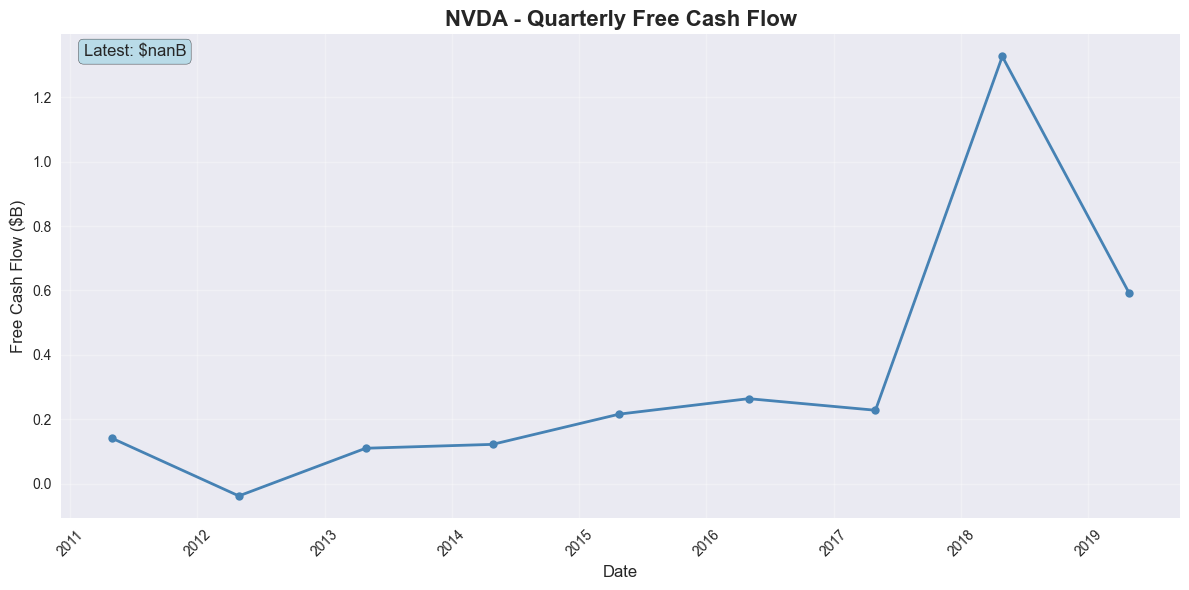

✓ Grafico salvato: result/NVDA_fcf_quarterly.png


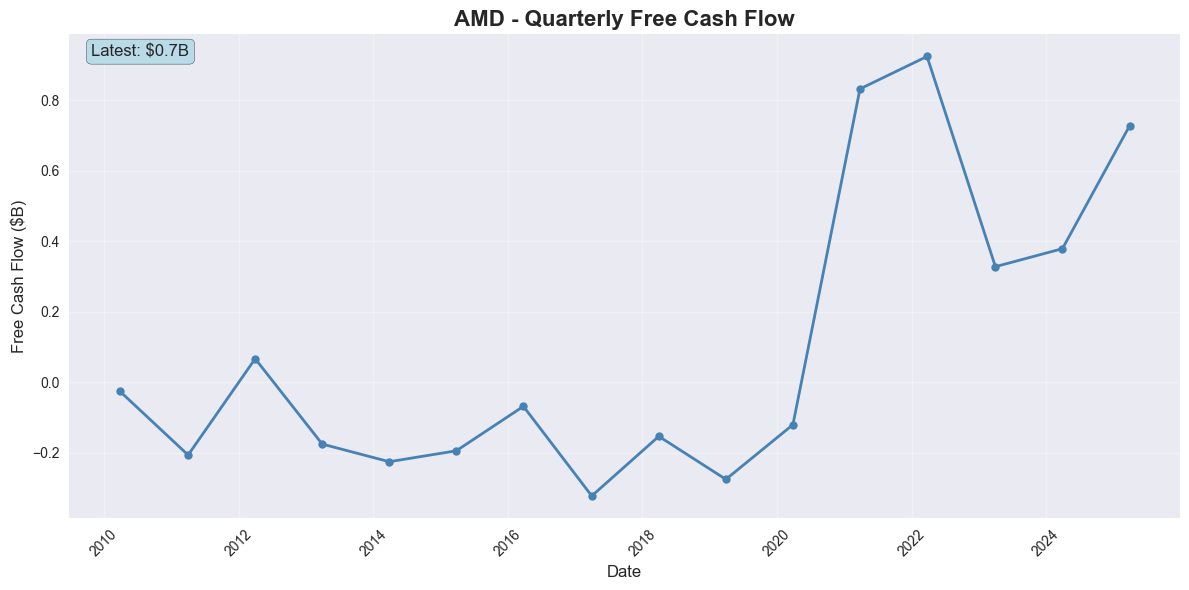

✓ Grafico salvato: result/AMD_fcf_quarterly.png


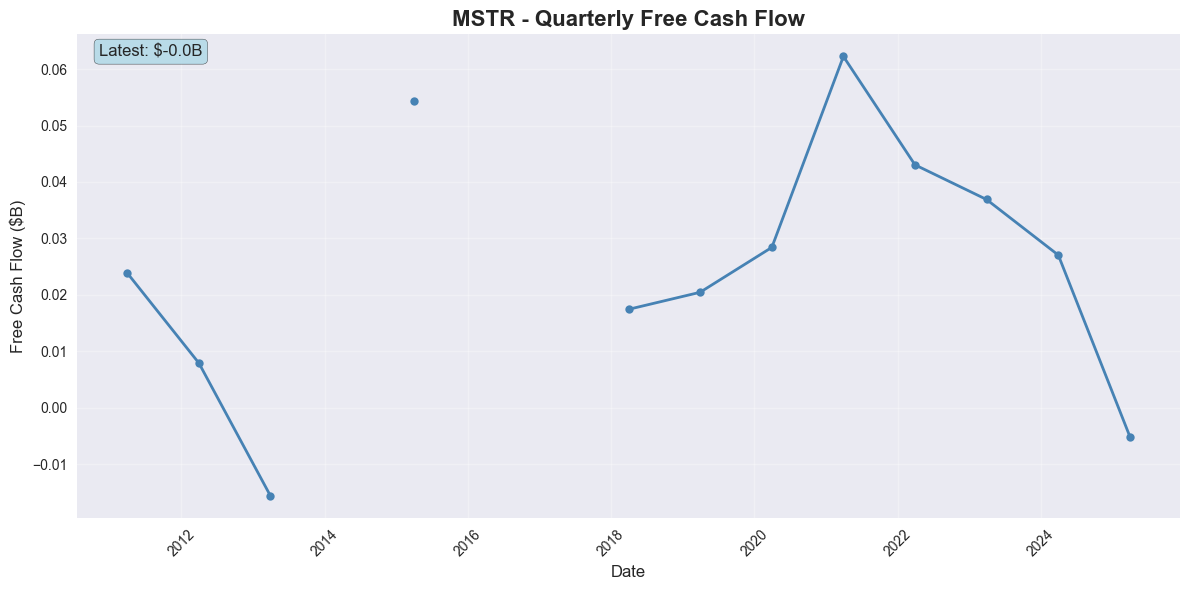

✓ Grafico salvato: result/MSTR_fcf_quarterly.png


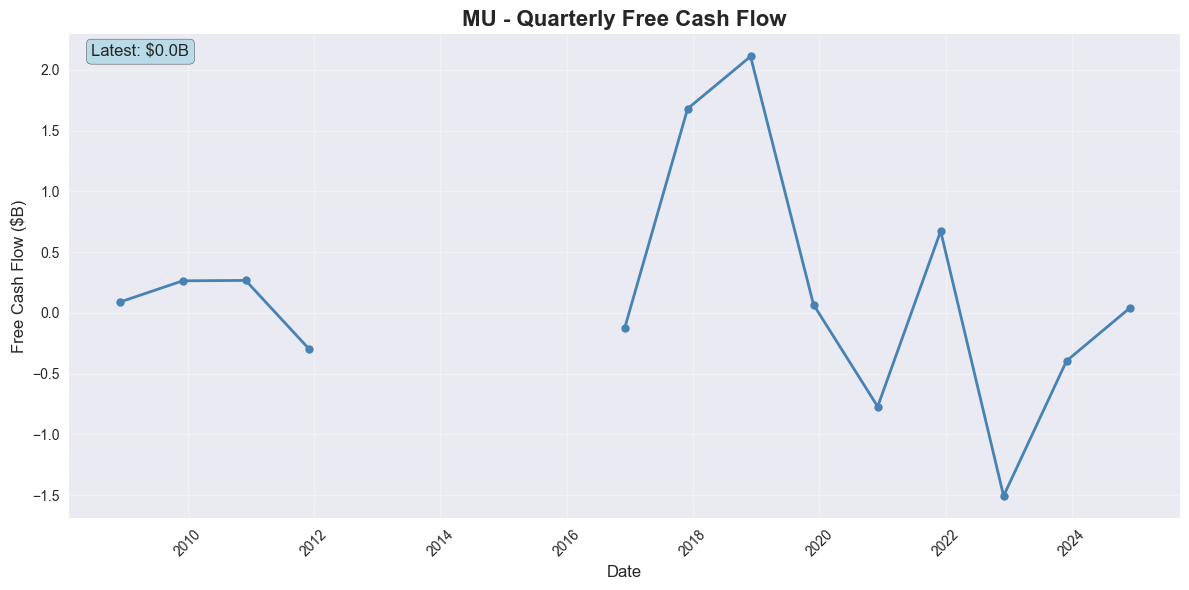

✓ Grafico salvato: result/MU_fcf_quarterly.png


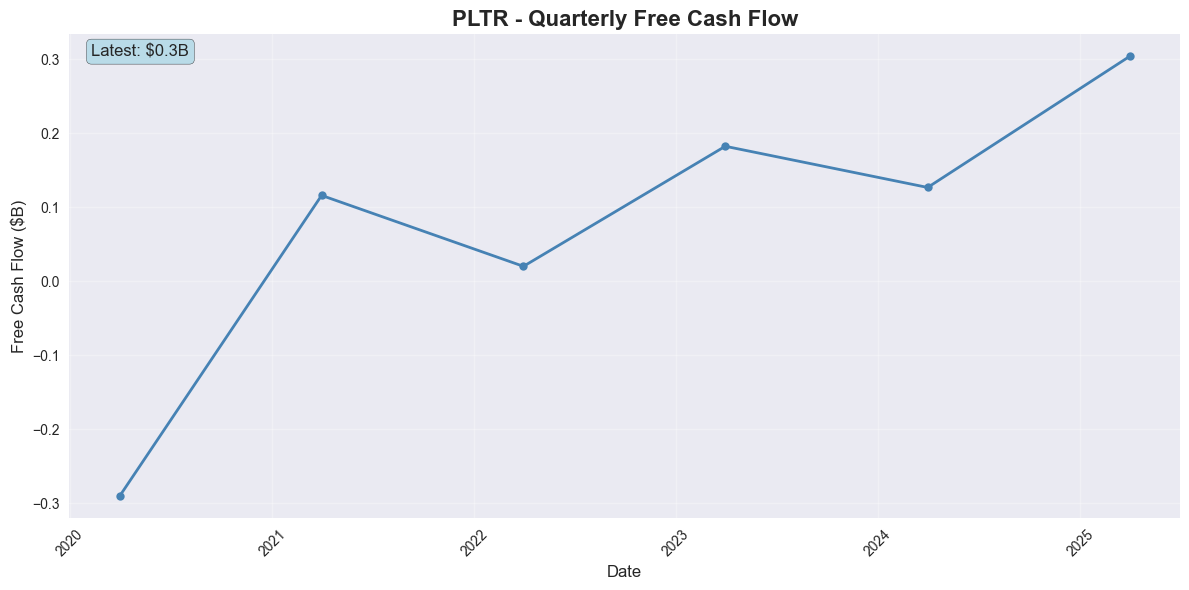

✓ Grafico salvato: result/PLTR_fcf_quarterly.png


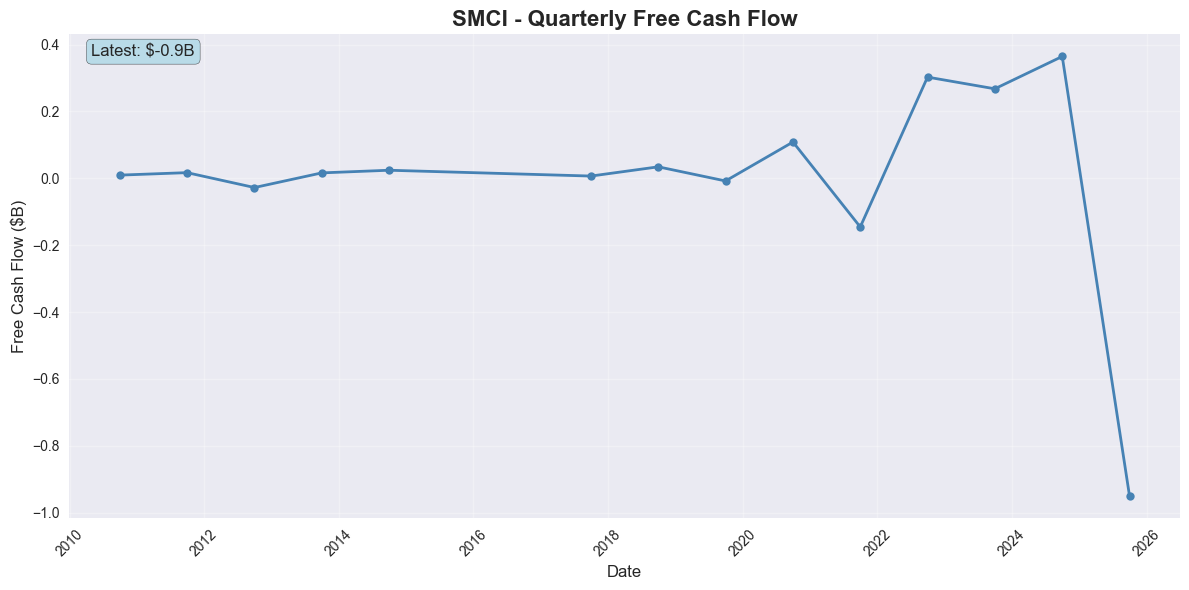

✓ Grafico salvato: result/SMCI_fcf_quarterly.png
✓ Tutti i grafici individuali completati


In [5]:
# Configurazione plot
plt.style.use('seaborn-v0_8')

# Crea la cartella result se non esiste
os.makedirs('result', exist_ok=True)

for ticker in TICKERS:
    filename = f"data/{ticker}_fcf_history.csv"

    if os.path.exists(filename):
        # Leggi il CSV
        df = pd.read_csv(filename)

        # Filtra solo dati trimestrali (10-Q)
        quarterly = df[df['form'] == '10-Q'].copy()

        if not quarterly.empty:
            # Converti date e ordina
            quarterly['end'] = pd.to_datetime(quarterly['end'])
            quarterly = quarterly.sort_values('end')

            # Converti FCF in miliardi
            quarterly['FCF_B'] = quarterly['Free Cash Flow'] / 1_000_000_000

            # Crea plot individuale
            plt.figure(figsize=(12, 6))
            plt.plot(quarterly['end'], quarterly['FCF_B'],
                    marker='o', linewidth=2, markersize=6, color='steelblue')

            plt.title(f'{ticker} - Quarterly Free Cash Flow', fontsize=16, fontweight='bold')
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Free Cash Flow ($B)', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)

            # Aggiungi ultimo valore
            last_value = quarterly['FCF_B'].iloc[-1]
            plt.text(0.02, 0.98, f'Latest: ${last_value:.1f}B',
                    transform=plt.gca().transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round',
                    facecolor='lightblue', alpha=0.8))

            plt.tight_layout()
            plt.savefig(f'result/{ticker}_fcf_quarterly.png', dpi=300, bbox_inches='tight')
            plt.show()

            print(f"✓ Grafico salvato: result/{ticker}_fcf_quarterly.png")
        else:
            print(f"⚠ {ticker}: Nessun dato trimestrale disponibile")
    else:
        print(f"✗ {ticker}: File {filename} non trovato")

print("✓ Tutti i grafici individuali completati")